In [70]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import openpyxl


In [71]:
# Load finalized data
df = pd.read_csv('../data/processed/data_finalized.csv', 
                 encoding='cp1252',  # to account for regional data settings
                 parse_dates=['date_dt']) # data is csv, date_dt needs to be parsed as date on loading

In [72]:
meta_lib_path = '../data/metadata/meta_data_library.xlsx'
main = ['2020-01-01', '2025-12-31']
corona = ['2020-03-01', '2021-12-31']
energy_crisis = ['2022-01-01', '2023-12-31']

In [73]:
"""
EDA Visualization Functions for Energy Market Analysis v1
Clean reimplementation
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.dates import MonthLocator, DateFormatter

# Set style
sns.set_style("whitegrid", {"grid.alpha": 0.11})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_meta_labels(meta_path):
    """Load label and unit mappings from meta_data_library."""
    from pathlib import Path
    
    file_ext = Path(meta_path).suffix.lower()
    
    try:
        if file_ext in ['.xlsx', '.xls']:
            meta = pd.read_excel(meta_path)
        else:
            encodings = ['utf-8', 'cp1252', 'iso-8859-1']
            delimiters = [',', ';']
            meta = None
            for encoding in encodings:
                for delimiter in delimiters:
                    try:
                        meta = pd.read_csv(meta_path, encoding=encoding, delimiter=delimiter)
                        if len(meta.columns) >= 2:
                            break
                    except:
                        continue
                if meta is not None and len(meta.columns) >= 2:
                    break
            if meta is None:
                raise Exception("Could not read file")
        
        label_dict = dict(zip(meta['column'], meta['label']))
        unit_dict = dict(zip(meta['column'], meta['unit']))
        return label_dict, unit_dict
        
    except Exception as e:
        print(f"Warning: Could not load meta_data_library: {e}")
        return {}, {}

def get_label(column, label_dict):
    """Get label for column or return column name as fallback."""
    if column in label_dict:
        return label_dict[column]
    else:
        print(f"Warning: meta_data_library incomplete. Displaying column name instead: {column}")
        return column

def get_unit(column, unit_dict):
    """Get unit for column or return empty string as fallback."""
    if column in unit_dict:
        unit = unit_dict[column]
        return unit if pd.notna(unit) else ""
    return ""

def format_date_ym(date_str):
    """Format date string to YYYY-MM."""
    return date_str[:7]

# =============================================================================
# PLOT FUNCTIONS
# =============================================================================

def single_plot(df, column, time_window, aggregation_level, meta_library_path,
                figsize=(12, 6)):
    """Plot single time series variable."""
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    label = get_label(column, label_dict)
    unit = get_unit(column, unit_dict)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df_filtered['date_dt'], df_filtered[column], linewidth=2)
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax.set_title(f"{label} Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel(unit if unit else label, fontsize=12)
    
    # Format x-axis
    ax.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.11)
    
    plt.tight_layout()
    plt.show()


def dual_axis_plot(df, primary_columns, secondary_columns, time_window, aggregation_level,
                   meta_library_path, figsize=(12, 7)):
    """Plot multiple variables on dual y-axes with legend below."""
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create figure with GridSpec: plot area + legend area
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 1, height_ratios=[8, 1], hspace=0.3)
    
    # Main plot
    ax1 = fig.add_subplot(gs[0])
    ax2 = ax1.twinx()
    
    # Plot primary (left axis)
    for col in primary_columns:
        label = get_label(col, label_dict)
        ax1.plot(df_filtered['date_dt'], df_filtered[col], label=label, linewidth=2)
    
    # Plot secondary (right axis)
    for col in secondary_columns:
        label = get_label(col, label_dict)
        ax2.plot(df_filtered['date_dt'], df_filtered[col], label=label, 
                linewidth=2, linestyle='--')
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax1.set_title(f"Combined Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Date", fontsize=12)
    
    primary_unit = get_unit(primary_columns[0], unit_dict)
    secondary_unit = get_unit(secondary_columns[0], unit_dict)
    ax1.set_ylabel(primary_unit if primary_unit else "Primary Axis", fontsize=12)
    ax2.set_ylabel(secondary_unit if secondary_unit else "Secondary Axis", fontsize=12)
    
    # Format x-axis
    ax1.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax1.grid(True, alpha=0.11)
    
    # Legend in separate area below
    ax_legend = fig.add_subplot(gs[1])
    ax_legend.axis('off')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax_legend.legend(lines1 + lines2, labels1 + labels2, 
                    loc='center', ncol=3, frameon=True)
    
    plt.show()


def standard_axis_plot(df, columns, time_window, aggregation_level, meta_library_path,
                      figsize=(12, 7)):
    """Plot multiple variables with 0-100 normalization and legend below."""
    
    # Load metadata
    label_dict, unit_dict = load_meta_labels(meta_library_path)
    
    # Filter and prepare data
    df_filtered = df[df['aggregation_level'] == aggregation_level].copy()
    df_filtered = df_filtered[
        (df_filtered['date_dt'] >= time_window[0]) & 
        (df_filtered['date_dt'] <= time_window[1])
    ]
    df_filtered['date_dt'] = pd.to_datetime(df_filtered['date_dt'])
    
    # Create figure with GridSpec: plot area + legend area
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 1, height_ratios=[8, 1], hspace=0.3)
    
    # Main plot
    ax = fig.add_subplot(gs[0])
    
    # Normalize and plot each column
    for col in columns:
        col_data = df_filtered[col].dropna()
        if len(col_data) > 0:
            col_min = col_data.min()
            col_max = col_data.max()
            if col_max - col_min > 0:
                normalized = ((df_filtered[col] - col_min) / (col_max - col_min)) * 100
            else:
                normalized = df_filtered[col] * 0
            
            label = get_label(col, label_dict)
            ax.plot(df_filtered['date_dt'], normalized, label=label, linewidth=2)
    
    # Titles and labels
    start_ym = format_date_ym(time_window[0])
    end_ym = format_date_ym(time_window[1])
    ax.set_title(f"Combined Time Plot {start_ym} to {end_ym}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Normalized Scale (0-100)", fontsize=12)
    ax.set_ylim(-5, 105)
    
    # Format x-axis
    ax.xaxis.set_major_locator(MonthLocator(bymonth=[3, 6, 9, 12]))
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.11)
    
    # Legend in separate area below
    ax_legend = fig.add_subplot(gs[1])
    ax_legend.axis('off')
    
    lines, labels = ax.get_legend_handles_labels()
    ax_legend.legend(lines, labels, loc='center', ncol=3, frameon=True)
    
    plt.show()


# Example usage
"""
# Load data
df = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])

# Define paths and time windows
meta_lib_path = '../data/metadata/meta_data_library.xlsx'
main = ['2020-01-01', '2023-12-31']

# Single plot
single_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)

# Dual axis plot
dual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],
               main, 'monthly', meta_lib_path)

# Standard axis plot
standard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market'],
                   main, 'monthly', meta_lib_path)
"""

"\n# Load data\ndf = pd.read_csv('../data/processed/data_finalized.csv', parse_dates=['date_dt'])\n\n# Define paths and time windows\nmeta_lib_path = '../data/metadata/meta_data_library.xlsx'\nmain = ['2020-01-01', '2023-12-31']\n\n# Single plot\nsingle_plot(df, 'price_exaa_mean', main, 'monthly', meta_lib_path)\n\n# Dual axis plot\ndual_axis_plot(df, ['price_exaa_mean'], ['carbonprices_primary_market'],\n               main, 'monthly', meta_lib_path)\n\n# Standard axis plot\nstandard_axis_plot(df, ['price_exaa_mean', 'carbonprices_primary_market'],\n                   main, 'monthly', meta_lib_path)\n"

`price_exaa_mean` and `price_mc_auction_mean` experience significant overlap between 2020-12 and 2022-12, while extending backwards and forwards. In the period of overlap, their monthly are almost identical.

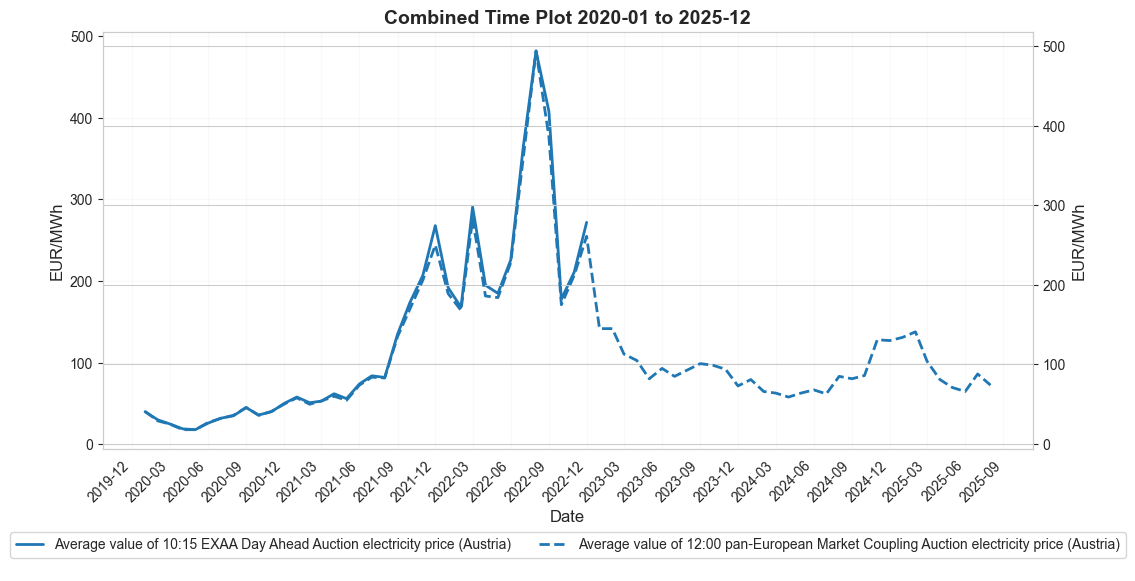

In [ ]:
# Demonstrating overlap of price_exaa_mean and price_mc_auction_mean
dual_axis_plot(df, ['price_exaa_mean'], ['price_mc_auction_mean'],
               main, 'monthly', meta_lib_path)


In [82]:
overlap = df[(df['price_exaa_mean'].notna()) & (df['price_mc_auction_mean'].notna())]
print("Correlation between price_exaa_mean and price_mc_auction_mean in overlapping periods")
print(overlap[['price_exaa_mean', 'price_mc_auction_mean']].corr())
print(20*"-")
print("")
print("Desciptive statistics for overlapping periods")
print(overlap[['price_exaa_mean', 'price_mc_auction_mean']].describe())

Correlation between price_exaa_mean and price_mc_auction_mean in overlapping periods
                       price_exaa_mean  price_mc_auction_mean
price_exaa_mean               1.000000               0.993711
price_mc_auction_mean         0.993711               1.000000
--------------------

Desciptive statistics for overlapping periods
       price_exaa_mean  price_mc_auction_mean
count      1291.000000            1291.000000
mean        135.553060             133.569326
std         127.762307             126.729262
min          -5.000000             -23.000000
25%          39.500000              39.000000
50%          76.000000              76.000000
75%         199.000000             199.000000
max         727.000000             764.000000


To maximise the amount of available data for analysis, a new feature is created `price_combined`, which consists of `price_exaa_mean` and `price_mc_auction_mean`only where only these prices are available and a mean of these two price signals where overlap exists.

In [ ]:
# Option 1: Averaging im Overlap + Fallbacks
df['price_combined'] = df[['price_exaa_mean', 'price_mc_auction_mean']].mean(axis=1, skipna=True)

# Option 2: Expliziter (falls du es dokumentieren willst)
def create_combined_price(row):
    exaa = row['price_exaa_mean']
    mc = row['price_mc_auction_mean']
    
    if pd.notna(exaa) and pd.notna(mc):
        return (exaa + mc) / 2  # Overlap: average
    elif pd.notna(exaa):
        return exaa  # Nur EXAA verfügbar
    else:
        return mc  # Nur MC verfügbar

df['price_combined'] = df.apply(create_combined_price, axis=1)